# 1D reactive transport in cement: HERMES benchmark with FEniCSx + GEMS

This notebook reproduces **`Cement_1D_ReactiveTransport_SNIA_doc.ipynb`** (EURAD HERMES
cement benchmark) with the four modules in `FEniCSx_GEMS_Beginner` (two folders up):

| Module | Role in this notebook |
|---|---|
| `chemistry.py` | loads GEMS, builds the sample and boundary-solution states, local equilibrium |
| `transport.py` | 1D mesh, boundary conditions, diffusion solve (FEniCSx, DG0 finite volume) |
| `coupling.py` | reads `case.yaml`, runs the SNIA time loop, checks mass balance |
| `output.py` | writes `profiles.csv`, `mass_balance.csv`, XDMF fields and a summary |

All settings live in **`case.yaml`** in this folder. The notebook only reads it, explains
each part, runs the model and compares the result with the HYDRUS reference profiles in
`Profile_HYDRUS.out`.

**Benchmark specification**

| Quantity | Value |
|---|---|
| Column length $L$ | 0.004 m (4 mm), 40 cells, $\Delta x$ = 0.1 mm |
| Porosity $\phi$ | 0.5 (500 g water per dm³ bulk), constant |
| Pore diffusion coefficient $D_p$ | $10^{-14}$ m²/s, same for all elements |
| Temperature, pressure | 25 °C, 1 bar |
| Sample (initial) | hydrated CaO 1.11 mol/dm³ + SiO₂ 0.31 mol/dm³, water scaled to 500 g |
| Left boundary | constant concentration: Cox-type water, CaCl₂ 14.6 mM, Si 0.18 mM, pH ≈ 7.6 |
| Right boundary | closed (zero flux) |
| Time | 1000 years, step 0.1 year, profiles every 100 years |

Run this notebook in the WSL `fenicsx` environment (the same Python used by `Run.cmd`),
which provides `dolfinx`, `petsc4py` and `xgems`.

## 1  Setup

The modules are imported from `FEniCSx_GEMS_Beginner` (two folders up). `read_case` performs the same checks as
`python coupling.py case.yaml`: exactly four sections, positive lengths and times,
$0 < \phi \le 1$, consistent feedback switches, and an existing GEMS project file.

In [7]:
import sys, math, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

HERE = Path.cwd()                     # this folder (exsample)
ROOT = HERE.parent.parent             # FEniCSx_GEMS_Beginner: chemistry.py, transport.py, ...
sys.path.insert(0, str(ROOT))

from coupling import read_case, run   # noqa: E402

CASE_FILE = HERE / "case.yaml"
config = read_case(CASE_FILE)

DAY = 86400.0
YEAR = 365.25 * DAY
ch, tr, cp, out = (config[k] for k in ("chemistry", "transport", "coupling", "output"))

print("GEMS project :", ch["project"])
print(f"Domain       : {tr['geometry']['length'] * 1e3:.1f} mm, {tr['geometry']['cells']} cells")
print(f"Material     : phi = {tr['material']['phi']},  De = {tr['material']['De']:.2e} m2/s")
print(f"Time         : dt = {cp['time']['dt'] / YEAR:g} yr, end = {cp['time']['end'] / YEAR:g} yr "
      f"=> {math.ceil(cp['time']['end'] / cp['time']['dt'] - 1e-9)} steps")
print(f"Feedback     : porosity {cp['update_porosity']}, diffusivity {cp['update_diffusivity']}")
print("Results      :", out["folder"])

GEMS project : /mnt/c/Users/xi_b/3D Objects/suduko/GEMS-FENICSX/FEniCSx_GEMS_Beginner/chemistry_data/b_time0-dat.lst
Domain       : 4.0 mm, 40 cells
Material     : phi = 0.5,  De = 5.00e-15 m2/s
Time         : dt = 0.1 yr, end = 1000 yr => 10000 steps
Feedback     : porosity False, diffusivity False
Results      : /mnt/c/Users/xi_b/3D Objects/suduko/GEMS-FENICSX/FEniCSx_GEMS_Beginner/example/demo_Cement_1D_benchmark/results_benchmark


### 1.1  Optional: shorter run

The full benchmark is 10 000 coupling steps × 40 cells = 400 000 GEMS equilibrations
(each cell starts cold, see `chemistry.py`). Set `END_YEARS` to run a shorter test first,
for example 200 years like the original notebook. `None` keeps the value in `case.yaml`.
The override only changes the copy in memory; `case.yaml` is not edited.

In [8]:
END_YEARS = None          # e.g. 200 for a quicker first run; None = use case.yaml (1000 yr)

if END_YEARS is not None:
    cp["time"]["end"] = END_YEARS * YEAR
    out["folder"] = str(Path(out["folder"]).with_name(Path(out["folder"]).name + f"_{END_YEARS:g}yr"))
    print(f"Running to {END_YEARS:g} yr; results go to {out['folder']}")
else:
    print(f"Running to {cp['time']['end'] / YEAR:g} yr as set in case.yaml")

Running to 1000 yr as set in case.yaml


## 2  Domain

The column is split into 40 equal **cells** (DG0: one value per cell, stored at the cell
centre). The left face $x=0$ touches the boundary solution; the right face $x=L$ is sealed.

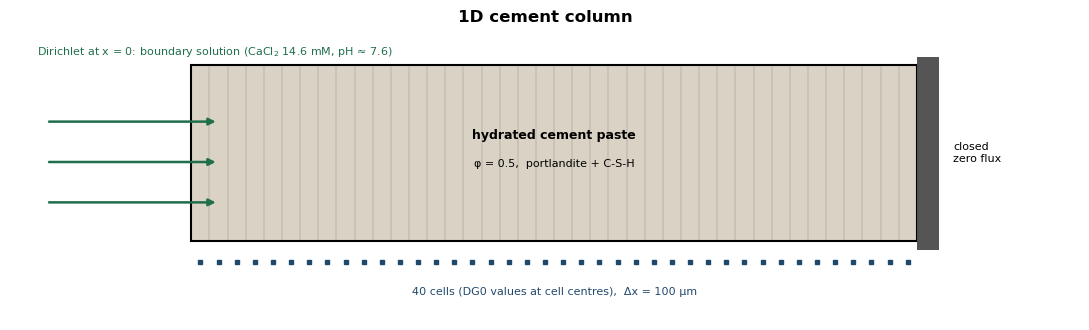

In [9]:
def draw_domain(ax, L_mm, n, phi):
    dx = L_mm / n
    ax.add_patch(mpatches.Rectangle((0, 0), L_mm, 1.0, facecolor="#d9d2c5", edgecolor="black", lw=1.5))
    for i in range(n + 1):
        ax.plot([i * dx] * 2, [0, 1], color="black", lw=0.3, alpha=0.35)
    xc = (np.arange(n) + 0.5) * dx
    ax.plot(xc, np.full(n, -0.12), "s", ms=2.5, color="#20486b", clip_on=False)
    ax.text(L_mm / 2, -0.26, f"{n} cells (DG0 values at cell centres),  Δx = {dx * 1e3:.0f} µm",
            ha="center", va="top", fontsize=8, color="#20486b")
    for y in (0.22, 0.45, 0.68):
        ax.annotate("", xy=(0.15, y), xytext=(-0.8, y),
                    arrowprops=dict(arrowstyle="-|>", color="#1f6f4a", lw=1.8))
    ax.text(-0.85, 1.06, "Dirichlet at x = 0: boundary solution (CaCl$_2$ 14.6 mM, pH ≈ 7.6)",
            fontsize=8, color="#1f6f4a")
    ax.add_patch(mpatches.Rectangle((L_mm, -0.05), 0.12, 1.1, facecolor="#555555"))
    ax.text(L_mm + 0.2, 0.5, "closed\nzero flux", fontsize=8, va="center")
    ax.text(L_mm / 2, 0.58, "hydrated cement paste", fontsize=9, ha="center", fontweight="bold")
    ax.text(L_mm / 2, 0.42, f"φ = {phi},  portlandite + C-S-H", fontsize=8, ha="center")
    ax.set_xlim(-1.0, L_mm + 0.9); ax.set_ylim(-0.45, 1.2); ax.axis("off")

fig, ax = plt.subplots(figsize=(11, 3.4))
draw_domain(ax, tr["geometry"]["length"] * 1e3, tr["geometry"]["cells"], tr["material"]["phi"])
ax.set_title("1D cement column", fontweight="bold")
plt.tight_layout(); plt.show()

## 3  Governing equations

### 3.1  Transport

The mobile quantity is the **total dissolved amount of each chemical element**
$j \in \{\mathrm{Ca}, \mathrm{Cl}, \mathrm{H}, \mathrm{O}, \mathrm{Si}\}$, including the H and O
of the water itself. Charge ($Z_z$) is not transported. All elements share one diffusion
coefficient, so no electromigration term is needed.

With $c_j$ the dissolved concentration in **mol per m³ of pore water**, `transport.py` solves

$$
\phi\,\frac{\partial c_j}{\partial t} \;=\; \frac{\partial}{\partial x}\!\left( D_e\,\frac{\partial c_j}{\partial x} \right),
\qquad
J_j = -D_e \frac{\partial c_j}{\partial x}\ \ [\mathrm{mol\,m^{-2}\,s^{-1}}]
$$

where $D_e$ is the **effective** diffusion coefficient (flux per unit bulk cross-section).
The benchmark notebook writes the same equation with the pore diffusion coefficient $D_p$:

$$
\phi\,\frac{\partial c_j}{\partial t} = \frac{\partial}{\partial x}\!\left(\phi D_p \frac{\partial c_j}{\partial x}\right)
\quad\Longrightarrow\quad
D_e = \phi\,D_p = 0.5 \times 10^{-14} = 5\times 10^{-15}\ \mathrm{m^2/s}.
$$

That is why `case.yaml` sets `De: 5.0e-15`. With constant $\phi$ both forms give
$\partial c/\partial t = D_p\,\partial^2 c/\partial x^2$.

### 3.2  Chemistry

Each cell is assumed to be in **local chemical equilibrium**. GEMS minimises the Gibbs
energy at fixed $T$, $P$ and element totals $\mathbf b$, and splits the totals between the
pore water and the solids:

$$
\mathbf b = \mathbf b^{\mathrm{aq}} + \mathbf b^{\mathrm{sol}}, \qquad
\min_{\mathbf n}\; G(\mathbf n)\ \ \text{subject to}\ \ \mathbf A^{\mathsf T}\mathbf n = \mathbf b .
$$

Here $\mathbf n$ are species amounts and $\mathbf A$ is the stoichiometry matrix. Only
$\mathbf b^{\mathrm{aq}}$ moves; the minerals (portlandite, C-S-H, amorphous silica) stay in
place until chemistry dissolves or precipitates them.

### 3.3  Units used by the code

| Array | Meaning | Unit |
|---|---|---|
| `total` | all of element $j$ in a cell | mol / m³ bulk |
| `aqueous` | element $j$ in the pore water | mol / m³ bulk |
| $c = $ `aqueous` $/ \phi$ | dissolved concentration | mol / m³ pore water |
| recipes in `case.yaml` | sample per 1 dm³ bulk; boundary solution per recipe | mol |

## 4  Discretisation in `transport.py`

### 4.1  Space: DG0 finite volume

Each cell $i$ holds one value $c_i$. Diffusion is carried by a **two-point flux** across each
internal face, with the harmonic mean of $D_e$ of the two neighbours:

$$
J_{i+1/2} = -\,\frac{D_{e,i+1/2}}{\Delta x}\,\bigl(c_{i+1} - c_i\bigr),
\qquad D_{e,i+1/2} = \frac{2 D_{e,i} D_{e,i+1}}{D_{e,i} + D_{e,i+1}} .
$$

### 4.2  Time: backward Euler

$$
\phi_i\,\frac{c_i^{n+1} - c_i^{n}}{\Delta t}\,\Delta x
 = -\bigl(J_{i+1/2}^{n+1} - J_{i-1/2}^{n+1}\bigr)
$$

This is implicit: each step solves one small linear system (PETSc, `preonly` + `lu`). It is
**unconditionally stable**, so the 0.1-year coupling step is used directly. The benchmark
notebook used explicit FTCS, whose Fourier number $r = D\,\Delta t/\Delta x^2 \approx 3.2 > 1/2$
forced 8 transport sub-steps per coupling step.

### 4.3  Boundary conditions

* **Left, Dirichlet.** The face value is the boundary-solution concentration $c_{\mathrm{in}}$.
  The face lies $\Delta x/2$ from the first cell centre, so
  $J_{1/2} = -\dfrac{2 D_e}{\Delta x}\bigl(c_1 - c_{\mathrm{in}}\bigr)$.
* **Right, zero flux.** $J_{N+1/2} = 0$.

Difference to the benchmark notebook: there the grid has **41 nodes** and node 0 *is* the
boundary (it is held at $c_{\mathrm{in}}$ and re-equilibrated). Here the first unknown sits
0.05 mm inside the column. Profiles therefore differ slightly within the first cell.

In [10]:
dx = tr["geometry"]["length"] / tr["geometry"]["cells"]
Dp = tr["material"]["De"] / tr["material"]["phi"]
r = Dp * cp["time"]["dt"] / dx**2
print(f"dx = {dx:.2e} m,  Dp = De/phi = {Dp:.1e} m2/s")
print(f"Fourier number r = Dp*dt/dx^2 = {r:.2f}  "
      f"({'explicit FTCS would be unstable (r > 0.5)' if r > 0.5 else 'explicit would be stable'})")
print("Backward Euler is unconditionally stable: no sub-steps needed.")

dx = 1.00e-04 m,  Dp = De/phi = 1.0e-14 m2/s
Fourier number r = Dp*dt/dx^2 = 3.16  (explicit FTCS would be unstable (r > 0.5))
Backward Euler is unconditionally stable: no sub-steps needed.


### 4.4  Check the transport operator against an analytic solution

Before coupling, `Transport` is tested alone on diffusion into a semi-infinite medium,
initially at $c=0$, with the face held at $c=1$:

$$
c(x,t) = \operatorname{erfc}\!\left(\frac{x}{2\sqrt{D t}}\right)
$$

The test domain is long enough that the closed right end is never reached. The residual
error comes from the first-order backward-Euler time step.

200 backward-Euler steps, max |numerical - analytic| = 6.96e-04


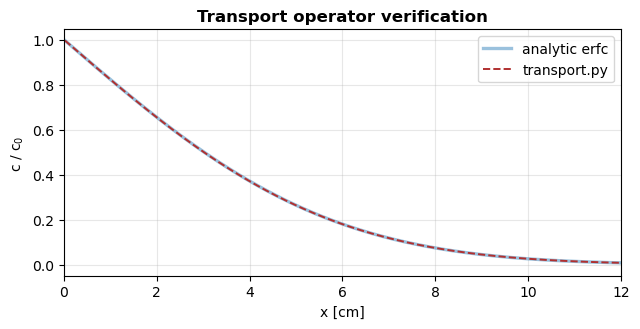

In [11]:
from transport import Transport

def verify_transport(D=1e-9, L=0.30, n=600, t_end=1.0e6, n_steps=200):
    cfg = {"geometry": {"length": L, "cells": n},
           "boundary": {"left": {"type": "dirichlet", "concentrations": {"tracer": 1.0}},
                        "right": {"type": "no_flux", "concentrations": {"tracer": 0.0}}},
           "solver": {"ksp_type": "preonly", "pc_type": "lu", "rtol": 1e-10, "max_iterations": 1000}}
    t = Transport(cfg)
    try:
        bc = t.boundary_concentrations(["tracer"])
        a = np.zeros((n, 1)); phi = np.ones(n); De = np.full(n, D)   # phi = 1 -> De = D
        dt = t_end / n_steps
        for _ in range(n_steps):
            a, _ = t.step(a, phi, De, dt, bc, [0])
        order = np.argsort(t.x)
        x, c = t.x[order], a[order, 0]
    finally:
        t.close()
    exact = np.array([math.erfc(xi / (2 * math.sqrt(D * t_end))) for xi in x])
    err = np.max(np.abs(c - exact))
    print(f"{n_steps} backward-Euler steps, max |numerical - analytic| = {err:.2e}")
    assert err < 1e-2, "transport operator does not match the analytic solution"
    fig, ax = plt.subplots(figsize=(6.5, 3.4))
    ax.plot(x * 100, exact, lw=2.4, alpha=0.45, label="analytic erfc")
    ax.plot(x * 100, c, "--", color="#b03030", lw=1.4, label="transport.py")
    ax.set_xlim(0, 12); ax.set_xlabel("x [cm]"); ax.set_ylabel("c / c$_0$")
    ax.set_title("Transport operator verification", fontweight="bold"); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

verify_transport()

## 5  The SNIA coupling scheme in `coupling.py`

**SNIA** (Sequential Non-Iterative Approach): each time step does one transport solve and
then one chemistry solve, without iterating between them.

1. **Transport.** Only the dissolved part moves:
   `immobile = total - aqueous`, then `transport.step(...)` diffuses every element in
   `aqueous` (as $c = $ `aqueous`$/\phi$) and returns the new `aqueous` and the amount that
   entered through the boundary.
2. **Recombine.** `total = immobile + aqueous`. The cell is now out of equilibrium: the
   pore water changed but the solids did not.
3. **React.** `chemistry.equilibrate(total[i])` for every cell. GEMS dissolves or
   precipitates minerals and returns the new `aqueous`, pH and phase amounts.
4. **Check.** Column inventory − initial inventory must equal the cumulative boundary input
   (to 1e-9 mol/m²); otherwise the run stops.

$$
\mathbf b^{n+1} = \mathcal C\bigl(\mathcal T(\mathbf b^{n})\bigr), \qquad \text{applied once per step}
$$

Porosity and $D_e$ feedback (steps 4–5 in `coupling.run`) are **switched off** in
`case.yaml`, because the benchmark keeps $\phi$ and $D_p$ constant.

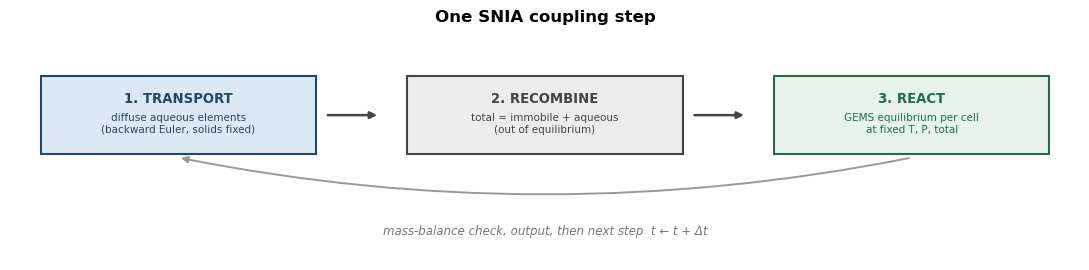

In [12]:
def draw_snia(ax):
    steps = [(0.2, "1. TRANSPORT", "diffuse aqueous elements\n(backward Euler, solids fixed)", "#dce9f5", "#20486b"),
             (2.6, "2. RECOMBINE", "total = immobile + aqueous\n(out of equilibrium)", "#ececec", "#444444"),
             (5.0, "3. REACT", "GEMS equilibrium per cell\nat fixed T, P, total", "#e6f2ea", "#1f6f4a")]
    w, y0, h = 1.8, 0.3, 0.44
    for x0, title, body, fc, ec in steps:
        ax.add_patch(mpatches.Rectangle((x0, y0), w, h, facecolor=fc, edgecolor=ec, lw=1.5))
        ax.text(x0 + w / 2, y0 + 0.29, title, ha="center", fontsize=9.5, fontweight="bold", color=ec)
        ax.text(x0 + w / 2, y0 + 0.12, body, ha="center", fontsize=7.5, color=ec)
    for xf in (2.0, 4.4):
        ax.annotate("", xy=(xf + 0.42, y0 + h / 2), xytext=(xf + 0.06, y0 + h / 2),
                    arrowprops=dict(arrowstyle="-|>", lw=1.8, color="#444444"))
    ax.annotate("", xy=(1.1, y0 - 0.02), xytext=(5.9, y0 - 0.02),
                arrowprops=dict(arrowstyle="-|>", lw=1.4, color="#999999", connectionstyle="arc3,rad=-0.10"))
    ax.text(3.5, -0.16, "mass-balance check, output, then next step  t ← t + Δt",
            ha="center", fontsize=8.5, color="#777777", style="italic")
    ax.set_xlim(0, 7); ax.set_ylim(-0.3, 1.0); ax.axis("off")

fig, ax = plt.subplots(figsize=(11, 2.8))
draw_snia(ax); ax.set_title("One SNIA coupling step", fontweight="bold")
plt.tight_layout(); plt.show()

## 6  Chemical system

`Chemistry(config['chemistry'])` loads the GEMS project, applies the two G⁰ adjustments,
checks the phase names and equilibrates the **boundary solution** once. Below, the
**sample** is also equilibrated once, to see the initial state every cell starts from.

In [13]:
from chemistry import Chemistry

chem = Chemistry(config["chemistry"])
names = chem.names
E = {n: i for i, n in enumerate(names)}
print("Elements (GEMS order):", names)
print("Solid phases reported:", chem.phases)

# Sample: case.yaml recipe per 1 dm3 bulk -> mol/m3 bulk
ic = chem.equilibrate(chem.initial)
print(f"\nSample after equilibration: pH = {ic['pH']:.3f}")
print(f"  pore-water volume fraction = {ic['water']:.4f}   (porosity in case.yaml: {tr['material']['phi']})")
print(f"  solid volume fraction      = {ic['solid']:.4f}")
for p, v in zip(chem.phases, ic["minerals"]):
    print(f"  {p:<14} {v / 1000:10.5f} mol/dm3 bulk")
print("\n  element     dissolved [mol/dm3 bulk]    total [mol/dm3 bulk]")
for n in names:
    if n == "Zz":
        continue
    print(f"  {n:<8}{ic['aqueous'][E[n]] / 1000:>20.6g}{chem.initial[E[n]] / 1000:>24.6g}")

Elements (GEMS order): ['Ca', 'Cl', 'H', 'O', 'Si', 'Zz']
Solid phases reported: ['CSHQ', 'Portlandite', 'Silica-amorph']

Sample after equilibration: pH = 12.453
  pore-water volume fraction = 0.5013   (porosity in case.yaml: 0.5)
  solid volume fraction      = 0.0482
  CSHQ              0.40707 mol/dm3 bulk
  Portlandite       0.60520 mol/dm3 bulk
  Silica-amorph     0.00000 mol/dm3 bulk

  element     dissolved [mol/dm3 bulk]    total [mol/dm3 bulk]
  Ca                0.00967389                 1.11922
  Cl                     1e-15                   1e-15
  H                    55.5276                 58.5223
  O                    27.7735                 31.0004
  Si               1.52728e-05                0.310001


In [14]:
# Boundary solution: equilibrated once in Chemistry.__init__; inlet_c is mol/m3 water.
print("Dirichlet concentrations of the boundary solution")
print("  element   mol/dm3 water")
for n in names:
    if n == "Zz":
        continue
    print(f"  {n:<8}{chem.inlet_c[E[n]] / 1000:>16.8f}")
print("\nExpected from the benchmark notebook: Ca 0.0146, Si 0.000183, Cl 0.0292 mol/dm3 (pH 7.59).")

Dirichlet concentrations of the boundary solution
  element   mol/dm3 water
  Ca            0.01455361
  Cl            0.02910525
  H           110.66402110
  O            55.33237634
  Si            0.00018242

Expected from the benchmark notebook: Ca 0.0146, Si 0.000183, Cl 0.0292 mol/dm3 (pH 7.59).


## 7  Run the coupled model

`run(config)` executes the whole SNIA loop of Section 5 and writes, in the results folder:

* `profiles.csv`: one row per cell and saved time (every `output.every` steps = 100 years)
* `mass_balance.csv`: inventory, boundary input and balance error, every step
* `fields.xdmf/.h5` (open in ParaView), `profiles.png`, `summary.txt`, `simulation.log`

The same run can be started outside Jupyter by double-clicking `Run.cmd` in this folder
(it runs `python ../../coupling.py case.yaml` in WSL). Then set `RUN_MODEL = False` below to
only post-process. Progress lines are printed at every saved profile. The full 1000-year run can take a while;
see Section 1.1 for a shorter test.

`output.py` switches Matplotlib to the non-interactive `Agg` backend for its own PNG, so the
inline backend is restored after the run.

In [15]:
# True : run the model here.
# False: skip the run and use results already written by Run.cmd
#        (python ../../coupling.py case.yaml) in the same results folder.
RUN_MODEL = True

if RUN_MODEL:
    t0 = time.time()
    state, diagnostics = run(config)
    print(f"\nFinished in {(time.time() - t0) / 60:.1f} min")
    print(f"max balance error      : {diagnostics['max_balance']:.2e} mol/m2")
    print(f"max GEMS reconstruction: {diagnostics['max_chemistry']:.2e} mol/m3")
    print(f"max water/phi mismatch : {diagnostics['max_water_mismatch']:.3%}")
else:
    print("Using existing results in", out["folder"])

step=0, time=0 s, balance=0.000e+00 mol/m2, chemistry=7.105e-12 mol/m3, water mismatch=0.25%
step=1000, time=3.15576e+09 s, balance=2.663e-11 mol/m2, chemistry=1.024e-04 mol/m3, water mismatch=0.03%
step=2000, time=6.31152e+09 s, balance=5.338e-11 mol/m2, chemistry=2.418e-08 mol/m3, water mismatch=0.03%
step=3000, time=9.46728e+09 s, balance=7.993e-11 mol/m2, chemistry=1.040e-07 mol/m3, water mismatch=0.03%
step=4000, time=1.2623e+10 s, balance=1.061e-10 mol/m2, chemistry=1.163e-06 mol/m3, water mismatch=0.03%
step=5000, time=1.57788e+10 s, balance=1.329e-10 mol/m2, chemistry=1.270e-06 mol/m3, water mismatch=0.03%
step=6000, time=1.89346e+10 s, balance=1.595e-10 mol/m2, chemistry=5.047e-07 mol/m3, water mismatch=0.03%
step=7000, time=2.20903e+10 s, balance=1.857e-10 mol/m2, chemistry=2.737e-07 mol/m3, water mismatch=0.03%
step=8000, time=2.52461e+10 s, balance=2.122e-10 mol/m2, chemistry=3.866e-08 mol/m3, water mismatch=0.03%
step=9000, time=2.84018e+10 s, balance=2.391e-10 mol/m2, che

In [16]:
%matplotlib inline
RESULTS = Path(out["folder"])
print((RESULTS / "summary.txt").read_text())

COMPLETED
Mode: coupled
Cells/states: 40; reference length: 0.004 m
Scheme: backward Euler, DG0 two-point cell flux (transport modes only)
Linear solver: preonly / lu
Final time: 31557600000.0 s; steps: 10000
Amounts: mol/m3 bulk; concentrations: mol/m3 pore water
Inventory and boundary exchange: mol/m2 (unit cross-sectional area)
Maximum balance error: 2.657989e-10 mol/m2
Maximum chemical element reconstruction error: 5.858994e-04 mol/m3
Maximum aqueous-volume/porosity mismatch: 0.253729%
GEMS initialisation: independent cold start for every equilibrium call
Final porosity range: 0.5 to 0.5
Final De range: 5e-15 to 5e-15 m2/s
Porosity feedback: False
Diffusivity feedback: False
Limit: numerical demonstration, not experimental validation.
Limit: saturated pore volume is assumed; aqueous volume mismatch is diagnostic only.



## 8  Convert to the benchmark's conventions

HYDRUS reports everything **per dm³ of bulk**. From `profiles.csv`:

$$
\text{X\_aq} = \frac{\phi\, c_{\text{X}}}{1000}, \qquad
\text{X\_s} = \frac{\text{total}_{\text{X}} - \phi\, c_{\text{X}}}{1000}, \qquad
\text{mineral} = \frac{\text{mineral}_{\text{mol/m}^3}}{1000}
$$

| Benchmark column | From this model |
|---|---|
| `pH` | `pH` |
| `Ca_aq`, `Si_aq` | dissolved Ca, Si |
| `Ca_s`, `Si_s` | Ca, Si in all solids |
| `Portlandite` | phase `Portlandite` |
| `AmorfSi` | phase `Silica-amorph` |
| `Ca_ss`, `Si_ss` | Ca and Si in C-S-H = solid Ca − portlandite, solid Si − amorphous silica |

Not compared: `H_aq`/`O_aq` in HYDRUS exclude the H and O of solvent water, and `mCSHQ` is
the **mass** of C-S-H (kg/dm³, e.g. 0.063 at t = 0). `profiles.csv` stores neither the
solvent-water amount nor phase masses; C-S-H is compared through `Ca_ss` and `Si_ss`. Cell centres
($x = 0.05, 0.15, \dots$ mm) are interpolated onto the benchmark nodes.

In [17]:
prof = pd.read_csv(RESULTS / "profiles.csv")
phi_col = prof["phi"]
sim = pd.DataFrame({"Time": np.round(prof["time_s"] / YEAR, 6),
                    "Distance": prof["x_m"],
                    "pH": prof["pH"]})
for n in ("Ca", "Si", "Cl"):
    aq = prof[f"{n}_c_mol_m3_water"] * phi_col
    sim[f"{n}_aq"] = aq / 1000
    sim[f"{n}_s"] = (prof[f"{n}_total_mol_m3_bulk"] - aq) / 1000
for col, phase in (("Portlandite", "Portlandite"), ("AmorfSi", "Silica-amorph")):
    sim[col] = prof[f"{phase}_mol_m3_bulk"] / 1000
# Ca and Si held in C-S-H: portlandite holds the other solid Ca, amorphous silica the other solid Si.
sim["Ca_ss"] = sim["Ca_s"] - sim["Portlandite"]
sim["Si_ss"] = sim["Si_s"] - sim["AmorfSi"]

bench = pd.read_csv(HERE / "Profile_HYDRUS.out", sep=r"\s+")
bench = bench.loc[:, ~bench.columns.str.startswith("Unnamed")]

print("Simulation times [yr]:", sorted(sim["Time"].unique()))
print("Benchmark times  [yr]:", sorted(bench["Time"].unique()))
sim.head()

Simulation times [yr]: [np.float64(0.0), np.float64(100.0), np.float64(200.0), np.float64(300.0), np.float64(400.0), np.float64(500.0), np.float64(600.0), np.float64(700.0), np.float64(800.0), np.float64(900.0), np.float64(1000.0)]
Benchmark times  [yr]: [np.float64(0.0), np.float64(100.0), np.float64(200.0), np.float64(300.0), np.float64(400.0), np.float64(500.0), np.float64(600.0), np.float64(700.0), np.float64(800.0), np.float64(900.0), np.float64(1000.0)]


,Time,Distance,pH,Ca_aq,Ca_s,Si_aq,Si_s,Cl_aq,Cl_s,Portlandite,AmorfSi,Ca_ss,Si_ss
0,0.0,0.00005,12.452522,0.009674,1.109544,0.000015,0.309986,1.000000e-15,0.0,0.605201,0.0,0.504343,0.309986
1,0.0,0.00015,12.452522,0.009674,1.109544,0.000015,0.309986,1.000000e-15,0.0,0.605201,0.0,0.504343,0.309986
2,0.0,0.00025,12.452522,0.009674,1.109544,0.000015,0.309986,1.000000e-15,0.0,0.605201,0.0,0.504343,0.309986
3,0.0,0.00035,12.452522,0.009674,1.109544,0.000015,0.309986,1.000000e-15,0.0,0.605201,0.0,0.504343,0.309986
4,0.0,0.00045,12.452522,0.009674,1.109544,0.000015,0.309986,1.000000e-15,0.0,0.605201,0.0,0.504343,0.309986


## 9  Mass balance

Equilibration conserves element totals, so any change in the column inventory must come
through the left boundary. Chlorine enters only from the boundary solution and should rise
monotonically; calcium leaches out and should fall. The balance error is the difference
between the two independent calculations and should stay near round-off.

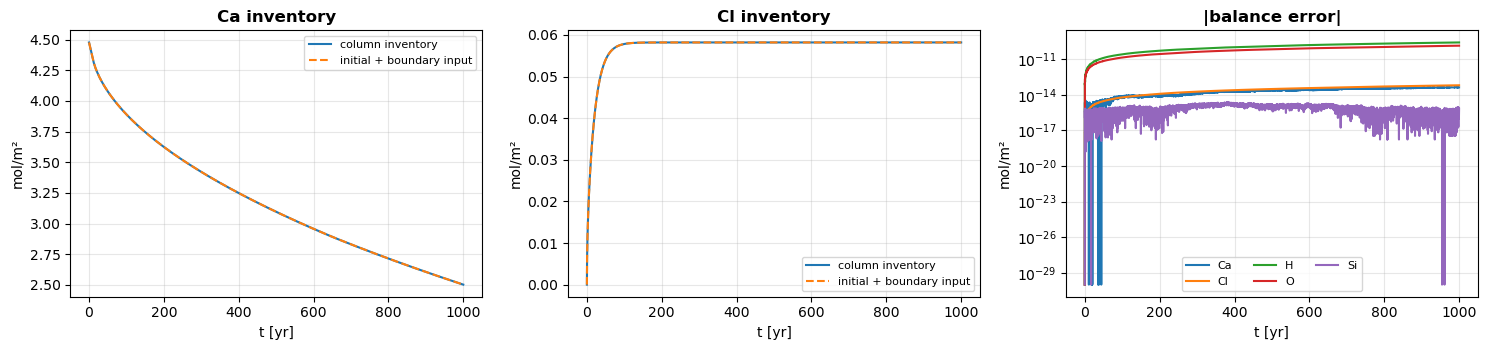

           inventory_mol_m2  cumulative_net_in_mol_m2  balance_error_mol_m2
component                                                                  
Ca                 2.502649                 -1.974223          4.307665e-14
Cl                 0.058210                  0.058210          6.487172e-14
H                229.180240                 -4.908804          2.657989e-10
O                119.510777                 -4.490736          1.413856e-10
Si                 1.223557                 -0.016449         -6.765422e-16
Zz                 0.000000                  0.000000          0.000000e+00


In [18]:
mb = pd.read_csv(RESULTS / "mass_balance.csv")
mb["t_yr"] = mb["time_s"] / YEAR
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for n, ax in zip(("Ca", "Cl"), axes[:2]):
    d = mb[mb["component"] == n]
    ax.plot(d["t_yr"], d["inventory_mol_m2"], label="column inventory")
    ax.plot(d["t_yr"], d["inventory_mol_m2"].iloc[0] + d["cumulative_net_in_mol_m2"], "--",
            label="initial + boundary input")
    ax.set_title(f"{n} inventory", fontweight="bold"); ax.set_xlabel("t [yr]"); ax.set_ylabel("mol/m²")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
for n in names:
    if n == "Zz":
        continue
    d = mb[mb["component"] == n]
    axes[2].semilogy(d["t_yr"], d["balance_error_mol_m2"].abs() + 1e-30, label=n)
axes[2].set_title("|balance error|", fontweight="bold"); axes[2].set_xlabel("t [yr]")
axes[2].set_ylabel("mol/m²"); axes[2].legend(fontsize=8, ncol=3); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

last = mb[mb["step"] == mb["step"].max()].set_index("component")
print(last[["inventory_mol_m2", "cumulative_net_in_mol_m2", "balance_error_mol_m2"]])

## 10  Comparison with the HYDRUS benchmark

Solid lines: HYDRUS reference. Dashed: this model. Dotted: difference (model − reference).

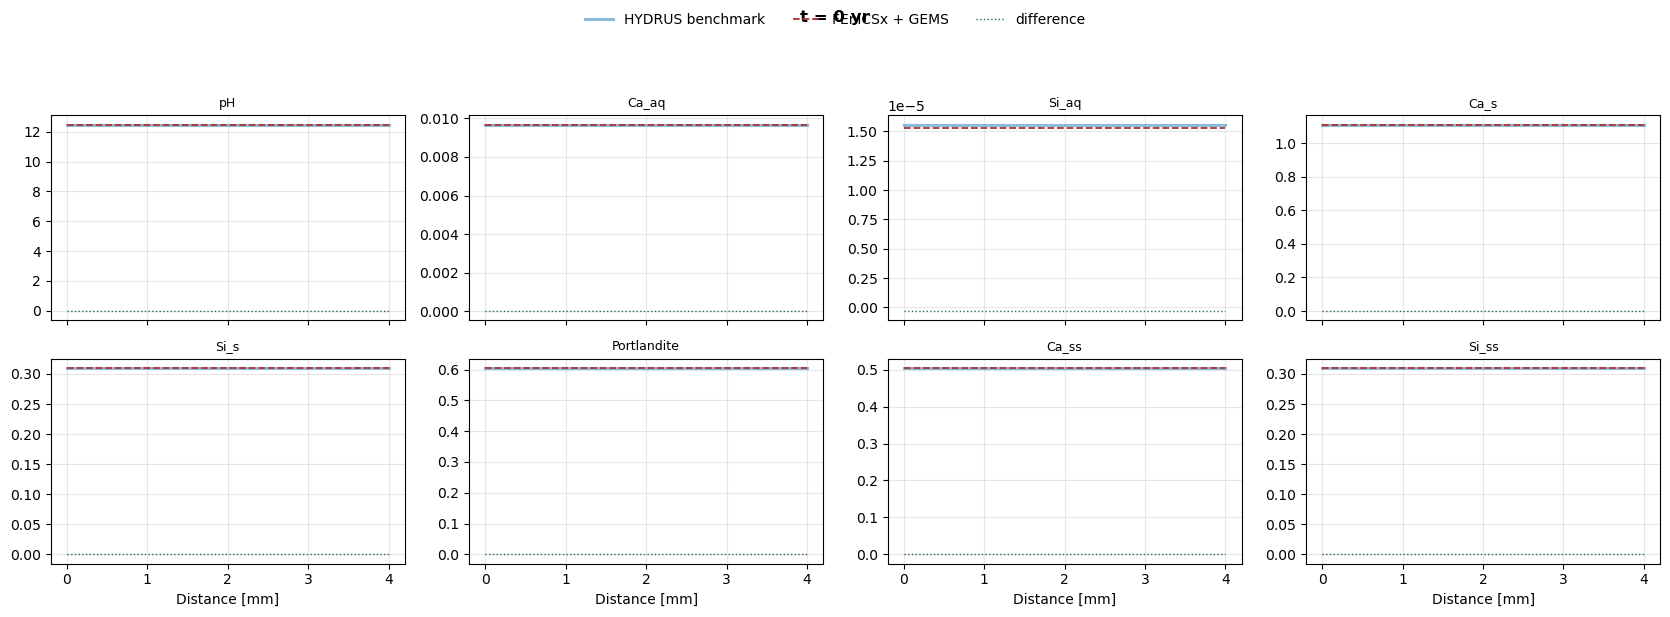

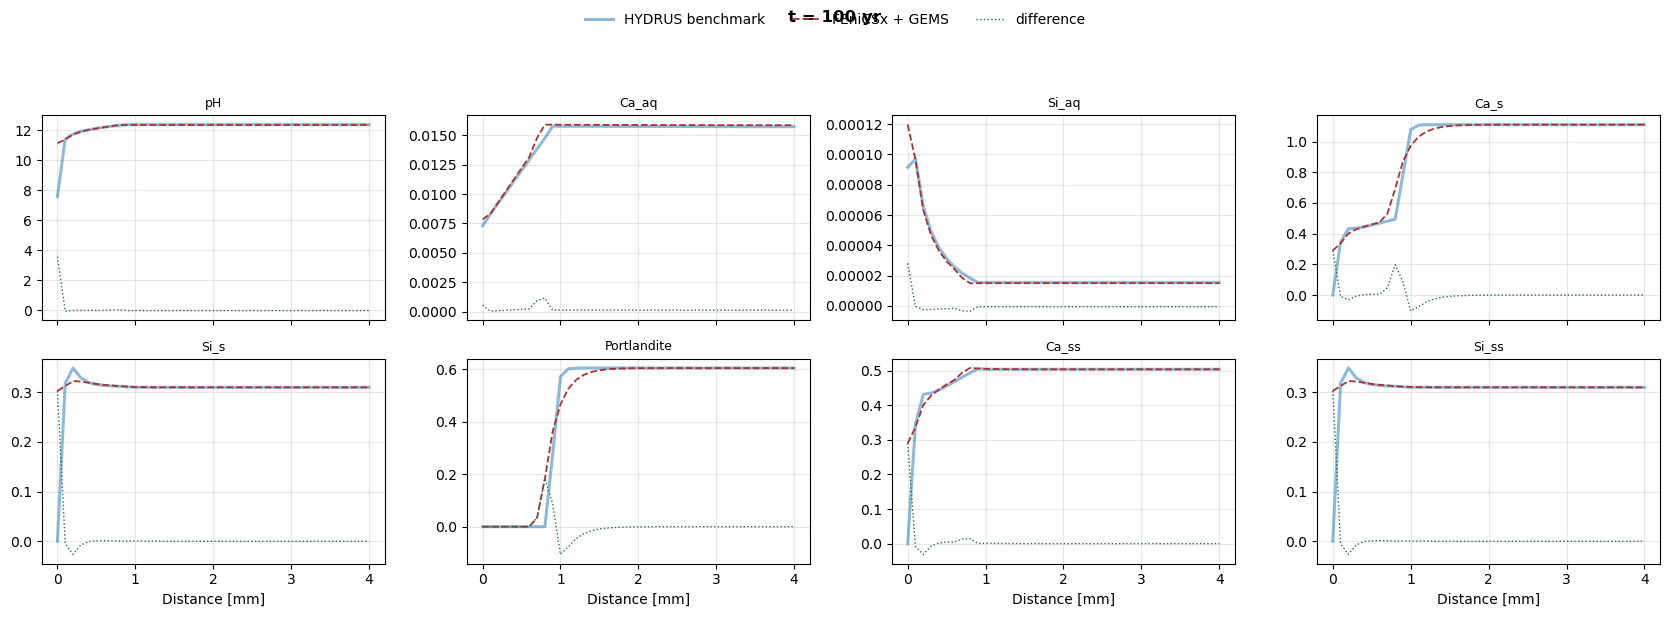

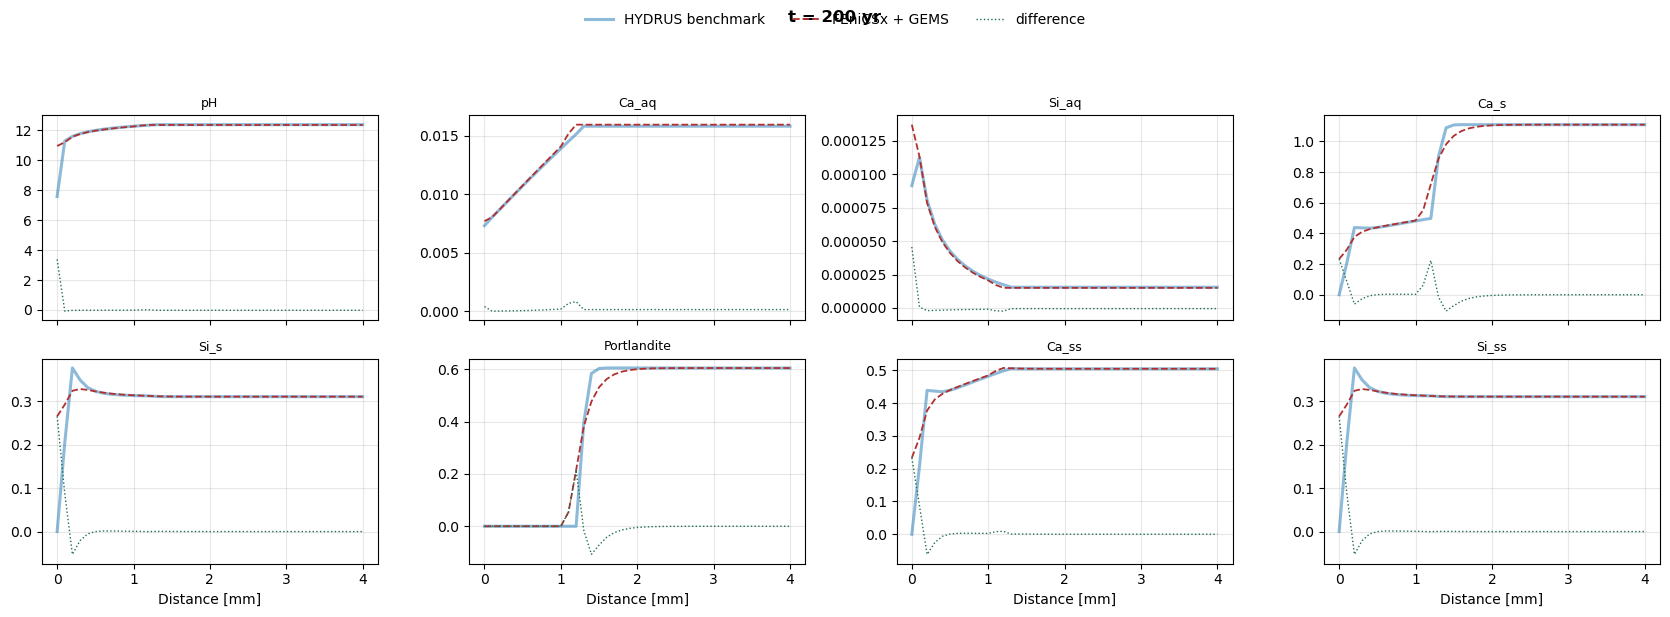

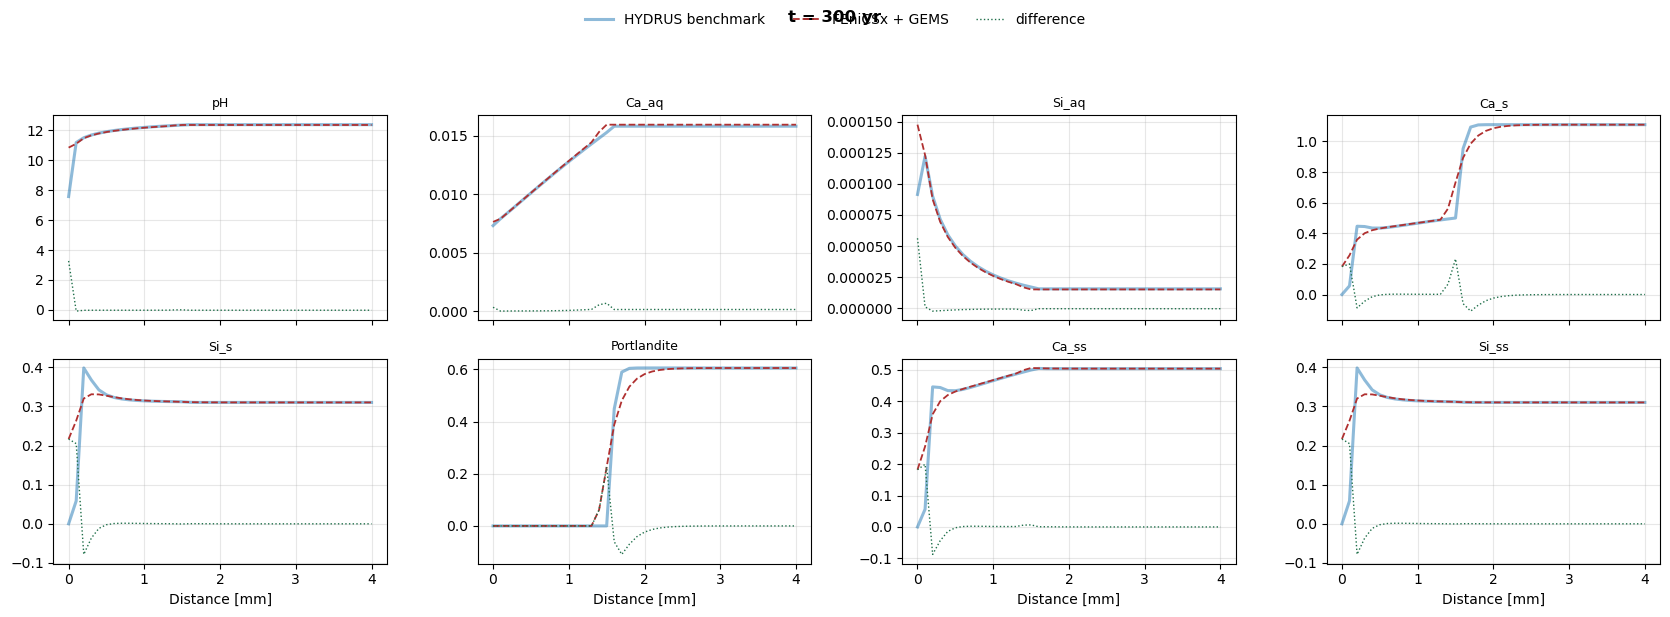

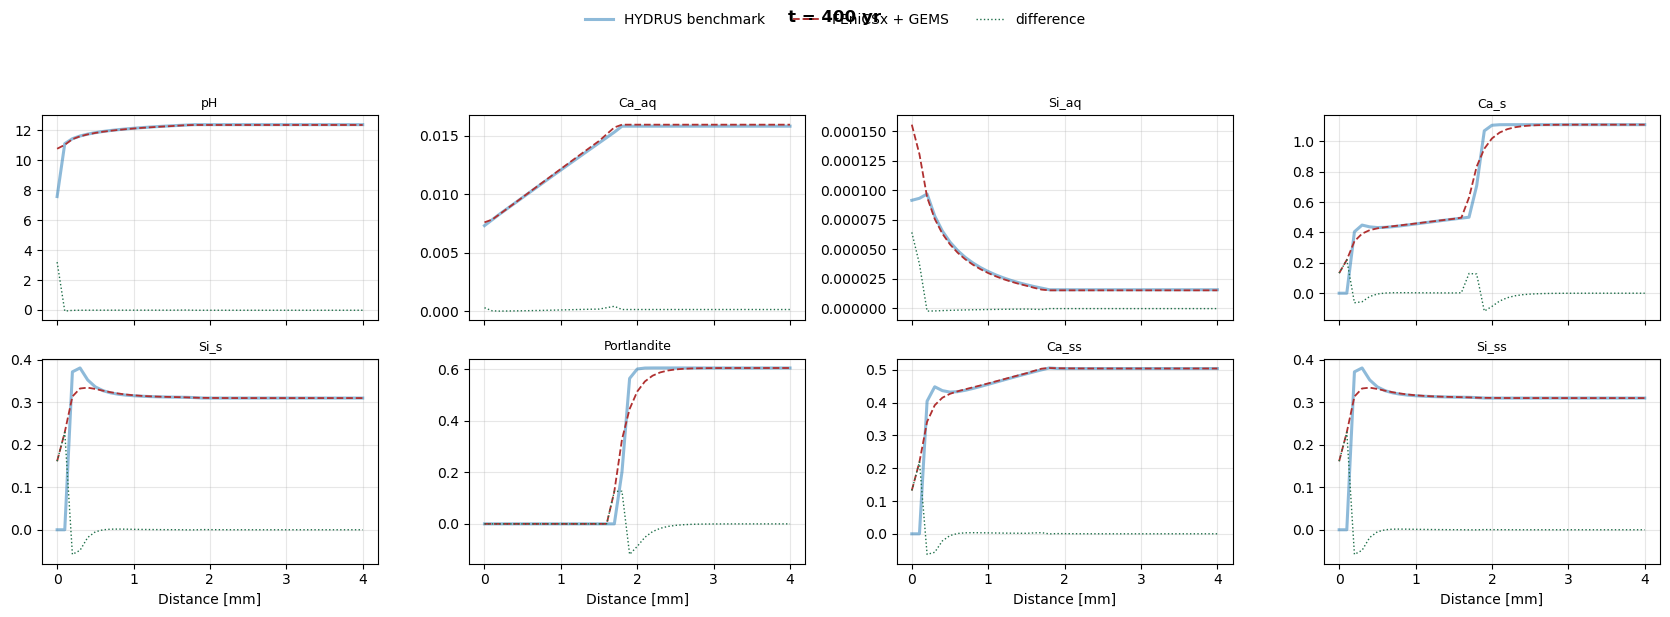

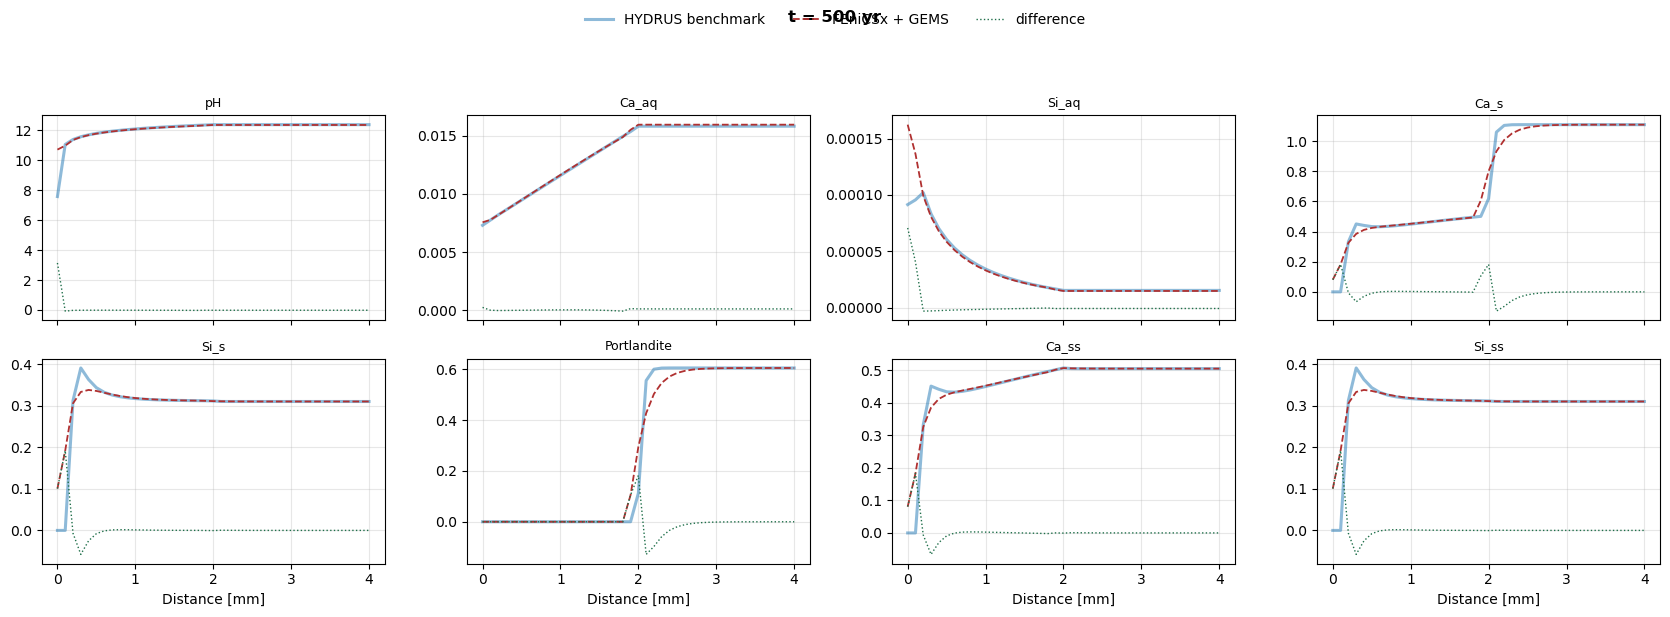

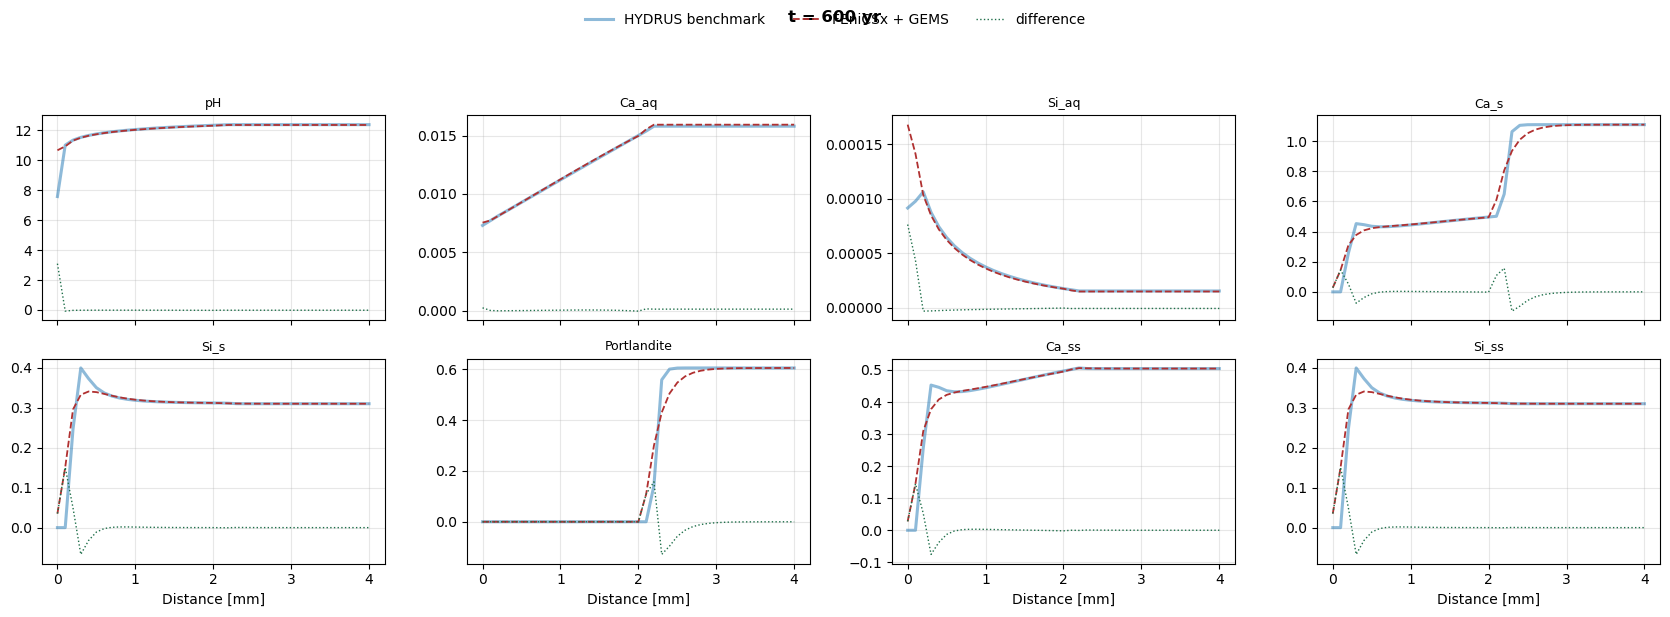

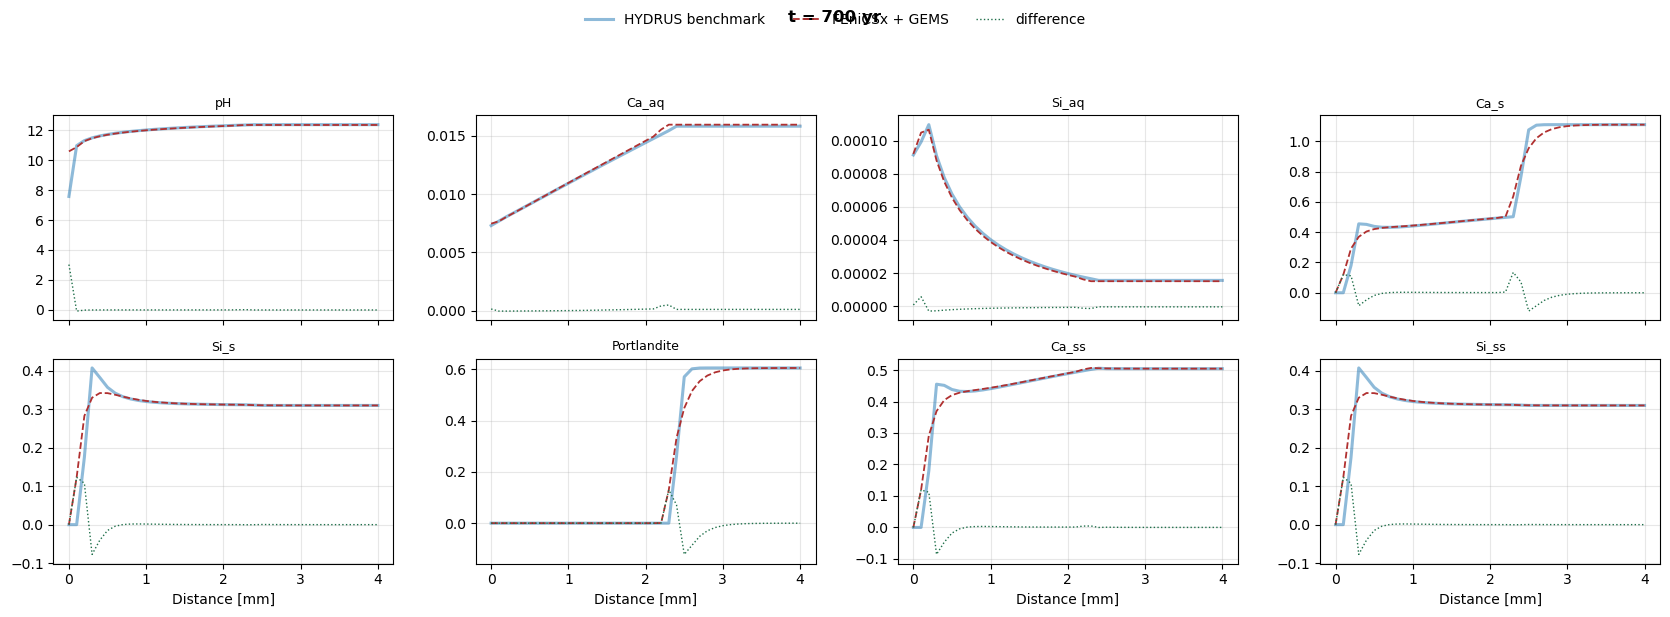

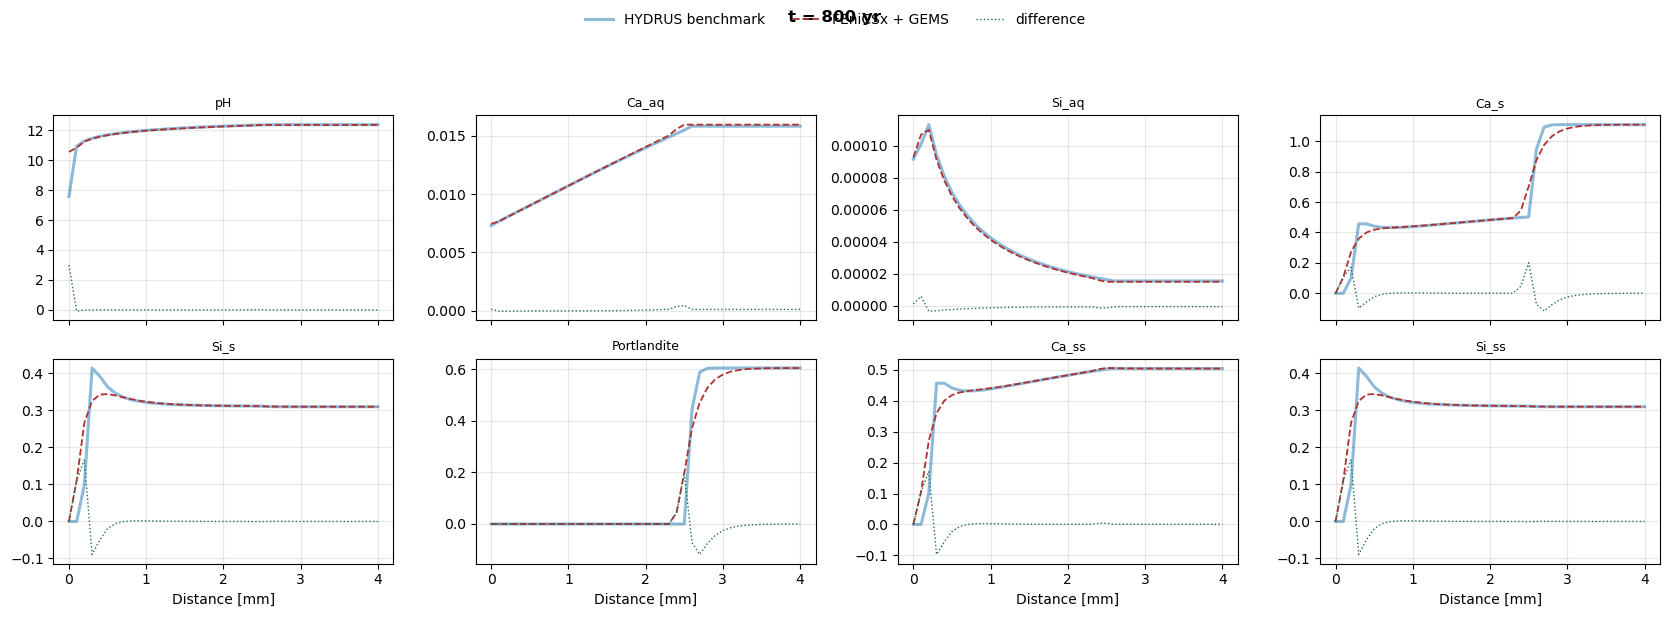

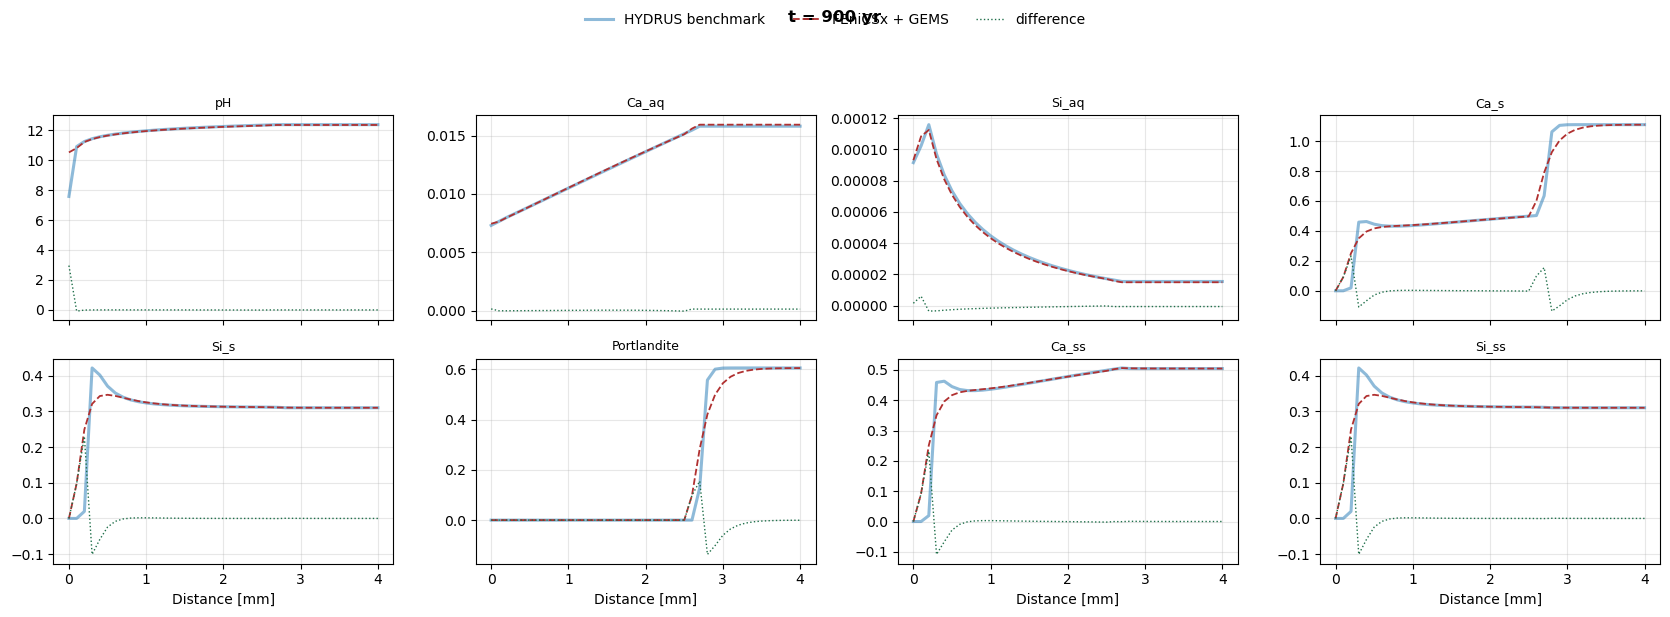

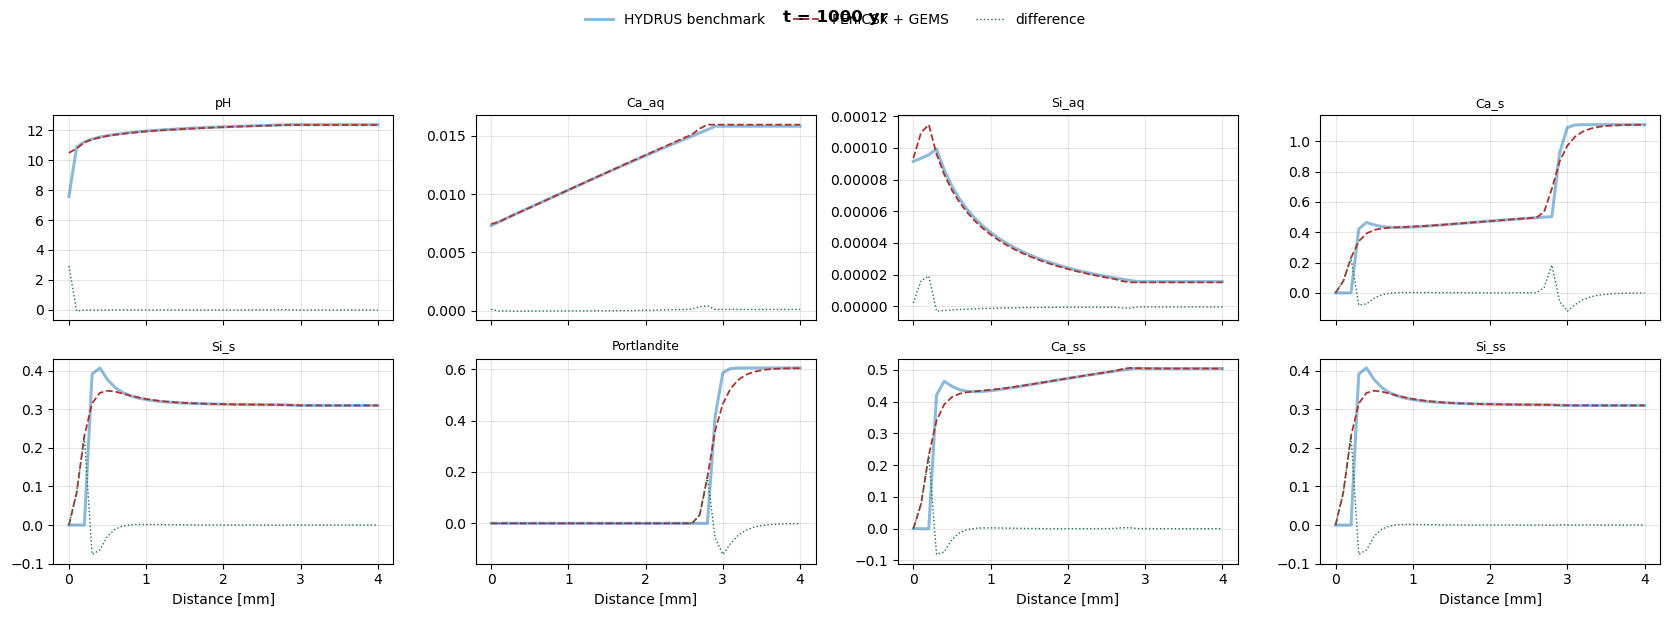

In [19]:
COMPARE = ["pH", "Ca_aq", "Si_aq", "Ca_s", "Si_s", "Portlandite", "Ca_ss", "Si_ss"]

def plot_comparison(t_yr, columns=COMPARE, ncols=4):
    b = bench[np.isclose(bench["Time"], t_yr)].sort_values("Distance")
    s = sim[np.isclose(sim["Time"], t_yr)].sort_values("Distance")
    if b.empty or s.empty:
        print(f"No data at t = {t_yr} yr (benchmark: {not b.empty}, simulation: {not s.empty})")
        return
    nrows = int(np.ceil(len(columns) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.0 * nrows), sharex=True)
    axes = np.atleast_1d(axes).ravel()
    xb = b["Distance"].to_numpy()
    for ax, col in zip(axes, columns):
        yb = b[col].to_numpy()
        ys = np.interp(xb, s["Distance"].to_numpy(), s[col].to_numpy())
        ax.plot(xb * 1e3, yb, "-", lw=2.2, alpha=0.5, label="HYDRUS benchmark")
        ax.plot(xb * 1e3, ys, "--", lw=1.3, color="#b03030", label="FEniCSx + GEMS")
        ax.plot(xb * 1e3, ys - yb, ":", lw=1.0, color="#1f6f4a", label="difference")
        ax.set_title(col, fontsize=9); ax.grid(alpha=0.3)
    for ax in axes[len(columns):]:
        ax.axis("off")
    for ax in axes[-ncols:]:
        ax.set_xlabel("Distance [mm]")
    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h, l, loc="upper center", ncol=3, frameon=False)
    fig.suptitle(f"t = {t_yr:g} yr", fontweight="bold", y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

for t_yr in sorted(sim["Time"].unique()):
    plot_comparison(t_yr)

### 10.1  Error summary

Root-mean-square difference per column and time, and the value range for scale.

In [20]:
rows = []
for t_yr in sorted(set(sim["Time"]).intersection(bench["Time"])):
    b = bench[np.isclose(bench["Time"], t_yr)].sort_values("Distance")
    s = sim[np.isclose(sim["Time"], t_yr)].sort_values("Distance")
    rec = {"t [yr]": t_yr}
    for col in COMPARE:
        ys = np.interp(b["Distance"], s["Distance"], s[col])
        rec[col] = float(np.sqrt(np.mean((ys - b[col].to_numpy()) ** 2)))
    rows.append(rec)
rms = pd.DataFrame(rows).set_index("t [yr]")
print("RMS difference (same units as the benchmark columns)")
display(rms.style.format("{:.2e}"))

RMS difference (same units as the benchmark columns)


,pH,Ca_aq,Si_aq,Ca_s,Si_s,Portlandite,Ca_ss,Si_ss
t [yr],,,,,,,,
0.000000,2.35e-02,1.10e-05,3.08e-07,5.58e-05,1.38e-05,8.89e-05,7.31e-05,1.38e-05
100.000000,5.58e-01,2.76e-04,4.54e-06,6.14e-02,4.75e-02,3.91e-02,4.58e-02,4.75e-02
200.000000,5.28e-01,2.09e-04,7.18e-06,5.83e-02,4.44e-02,4.09e-02,4.03e-02,4.44e-02
300.000000,5.12e-01,1.78e-04,8.83e-06,6.33e-02,4.85e-02,4.36e-02,4.50e-02,4.85e-02
400.000000,5.00e-01,1.43e-04,1.17e-05,5.67e-02,4.55e-02,3.75e-02,4.23e-02,4.55e-02
500.000000,4.91e-01,1.07e-04,1.28e-05,5.41e-02,3.53e-02,4.29e-02,3.32e-02,3.53e-02
600.000000,4.84e-01,1.02e-04,1.38e-05,4.90e-02,2.80e-02,4.05e-02,2.79e-02,2.80e-02
700.000000,4.72e-01,1.48e-04,1.52e-06,4.57e-02,2.90e-02,3.43e-02,2.99e-02,2.90e-02
800.000000,4.67e-01,1.31e-04,1.54e-06,5.49e-02,3.53e-02,4.09e-02,3.62e-02,3.53e-02


## 11  Degradation front

Where the portlandite front sits over time (position where portlandite falls to half its
initial value). Under diffusion control it follows $x_f \propto \sqrt{t}$, so a straight line
in the right-hand panel indicates the expected behaviour.

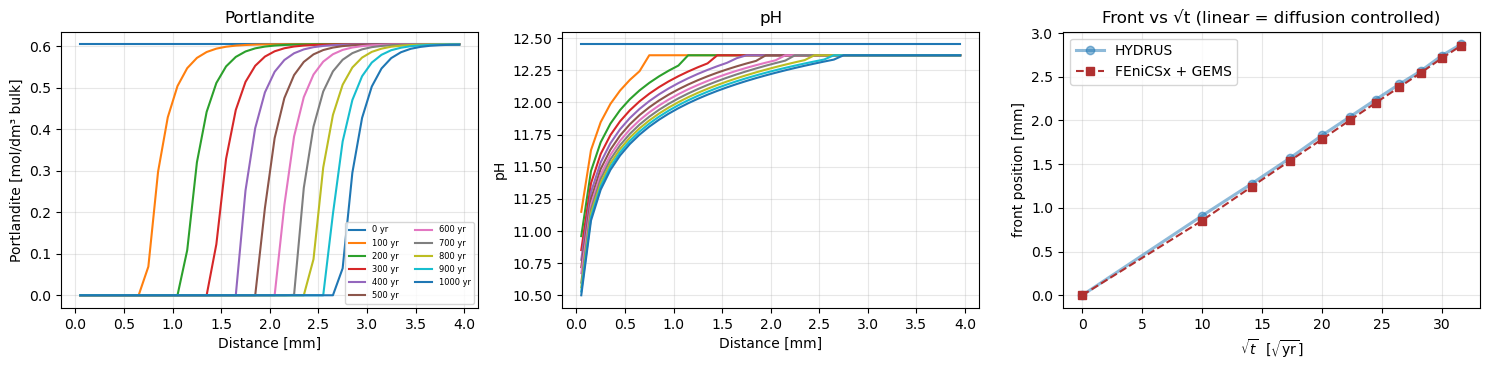

 t [yr]  front model [mm]  front HYDRUS [mm]
    0.0            0.0000             0.0000
  100.0            0.8536             0.9090
  200.0            1.2415             1.2763
  300.0            1.5373             1.5675
  400.0            1.7833             1.8279
  500.0            2.0047             2.0429
  600.0            2.2015             2.2384
  700.0            2.3797             2.4133
  800.0            2.5476             2.5682
  900.0            2.7109             2.7406
 1000.0            2.8554             2.8725


In [21]:
def front(df, t_yr, frac=0.5):
    d = df[np.isclose(df["Time"], t_yr)].sort_values("Distance")
    x, p = d["Distance"].to_numpy(), d["Portlandite"].to_numpy()
    p0 = df[np.isclose(df["Time"], 0.0)]["Portlandite"].max()
    f = p / p0
    above = np.where(f >= frac)[0]
    if above.size == 0:
        return np.nan
    i = above[0]
    if i == 0:
        return 0.0          # first cell still intact: no degraded zone yet
    w = (frac - f[i - 1]) / (f[i] - f[i - 1])
    return (x[i - 1] + w * (x[i] - x[i - 1])) * 1e3

times = np.array(sorted(sim["Time"].unique()))
f_sim = np.array([front(sim, t) for t in times])
f_ben = np.array([front(bench, t) for t in times])

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for t in times:
    d = sim[np.isclose(sim["Time"], t)].sort_values("Distance")
    axes[0].plot(d["Distance"] * 1e3, d["Portlandite"], label=f"{t:g} yr")
    axes[1].plot(d["Distance"] * 1e3, d["pH"])
axes[0].set(xlabel="Distance [mm]", ylabel="Portlandite [mol/dm³ bulk]", title="Portlandite")
axes[0].legend(fontsize=6, ncol=2)
axes[1].set(xlabel="Distance [mm]", ylabel="pH", title="pH")
axes[2].plot(np.sqrt(times), f_ben, "o-", alpha=0.5, lw=2.2, label="HYDRUS")
axes[2].plot(np.sqrt(times), f_sim, "s--", color="#b03030", label="FEniCSx + GEMS")
axes[2].set(xlabel=r"$\sqrt{t}$  [$\sqrt{\mathrm{yr}}$]", ylabel="front position [mm]",
            title="Front vs √t (linear = diffusion controlled)")
axes[2].legend()
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(pd.DataFrame({"t [yr]": times, "front model [mm]": f_sim, "front HYDRUS [mm]": f_ben}).round(4).to_string(index=False))

## 12  Summary of differences to the original notebook

| Aspect | Original notebook | This notebook |
|---|---|---|
| Transport solver | explicit FTCS, 8 sub-steps per 0.1 yr | FEniCSx DG0 finite volume, backward Euler, 1 step |
| Unknowns | 41 nodes, node 0 = boundary | 40 cell centres, boundary at the face |
| Diffusion parameter | $D_p = 10^{-14}$ m²/s | $D_e = \phi D_p = 5\times10^{-15}$ m²/s (same physics) |
| GEMS start | warm start from previous state | cold start in every cell and step |
| Mass-balance check | printed totals | enforced every step (run stops on failure) |
| Settings | Python constants in the notebook | `case.yaml` |

Chemistry (GEMS project, G⁰ adjustments, sample and boundary-solution recipes) is identical.
Expect small differences near $x = 0$ from the boundary placement, and first-order
time-discretisation differences from backward Euler.